In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [113]:
df = pd.read_csv("creditcard.csv")

In [114]:
print ("The size of the dataset :", df.shape)

The size of the dataset : (284807, 31)


In [115]:
pd.concat([df.head(2), df.tail(2)])

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [116]:
print ("Data structure:")
df.info()

Data structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64

In [117]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


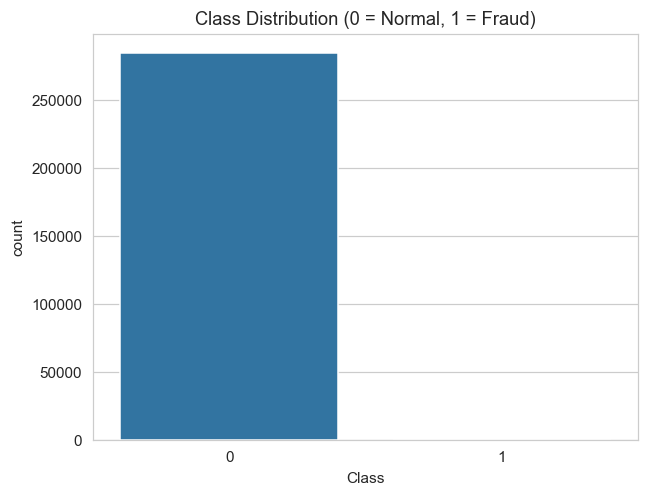

In [118]:
plt.figure()
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

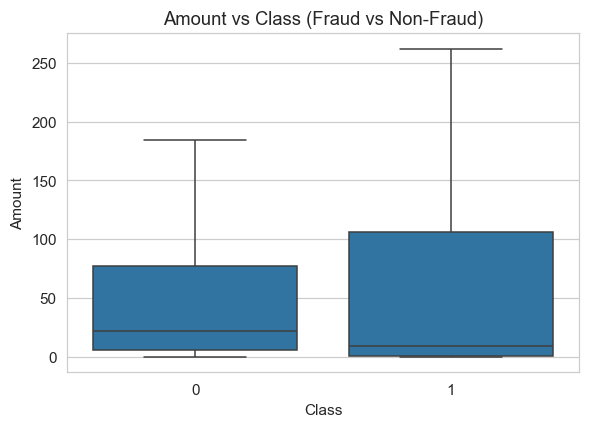

In [119]:
# 金额（Amount）与 Class 的箱线图
plt.figure(figsize=(6, 4))
sns.boxplot(x="Class", y="Amount", data=df, showfliers=False)
plt.title("Amount vs Class (Fraud vs Non-Fraud)")
plt.show()

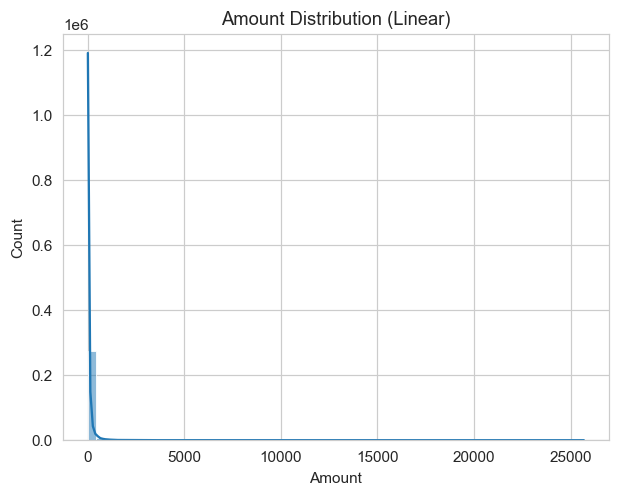

In [137]:
# 原始金额分布
sns.histplot(df["Amount"], bins=60, kde=True)
plt.title("Amount Distribution (Linear)")
plt.show()

In [122]:
#Check Missing Values
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

There is no missing values in the data set.

In [123]:
#Check Duplicates
df_cleaned = df.drop_duplicates()
print(df_cleaned.shape[0])

283726


Found 1,081 duplicates, after removing them, there are 283726 rows.

In [130]:
#极值截断
q_low, q_high = df_cleaned["Amount"].quantile([0.01, 0.99])
df_cleaned["Amount"] = df_cleaned["Amount"].clip(q_low, q_high)

/var/folders/b6/1b577y7s40qcng90bjp27y9c0000gn/T/ipykernel_22288/3826457274.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Amount"] = df_cleaned["Amount"].clip(q_low, q_high)


In [125]:
#特征工程
df_cleaned["Time_Hours"] = (df_cleaned["Time"] % 86400) / 3600
df_cleaned["Amount"] = np.log1p(df_cleaned["Amount"])

/var/folders/b6/1b577y7s40qcng90bjp27y9c0000gn/T/ipykernel_22288/2889810237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Time_Hours"] = (df_cleaned["Time"] % 86400) / 3600
/var/folders/b6/1b577y7s40qcng90bjp27y9c0000gn/T/ipykernel_22288/2889810237.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Amount"] = np.log1p(df_cleaned["Amount"])


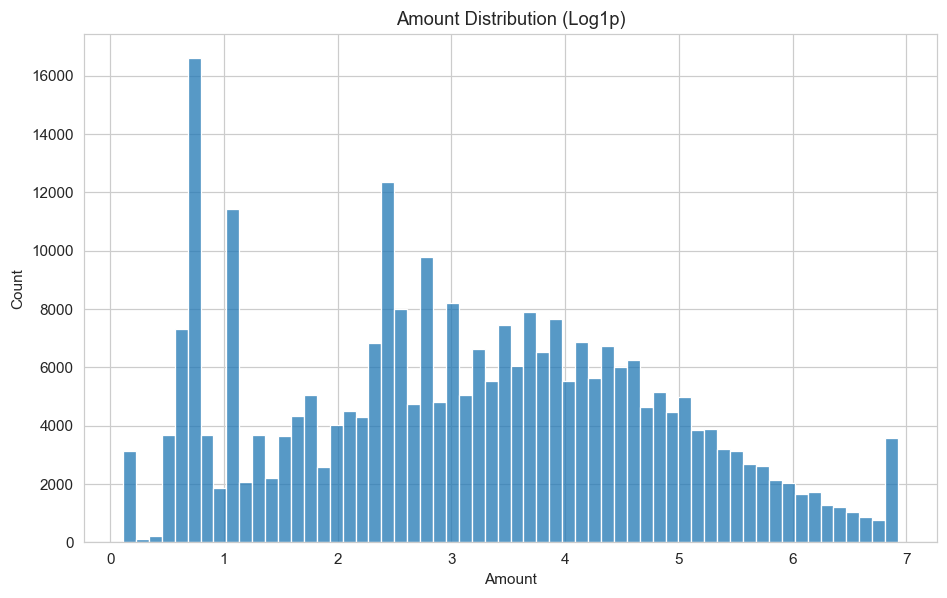

In [139]:
# 对数化后的金额分布
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned["Amount"], bins=60, kde=False)
plt.title("Amount Distribution (Log1p)")
plt.show()

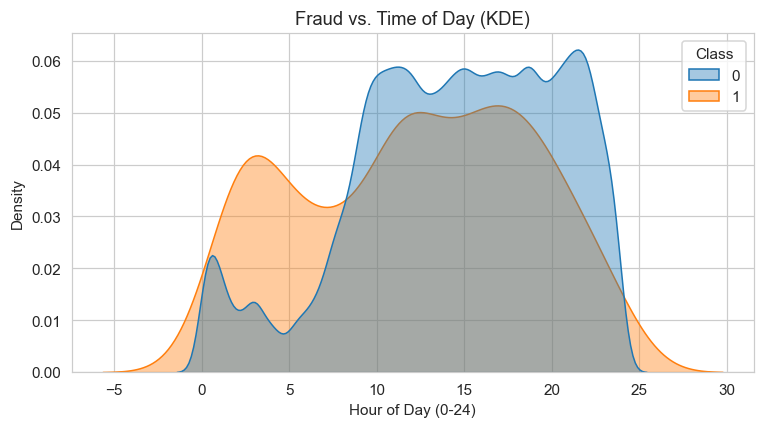

In [133]:
#24小时内欺诈KDE
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_cleaned, x="Time_Hours", hue="Class", fill=True, common_norm=False, alpha=0.4)
plt.title("Fraud vs. Time of Day (KDE)")
plt.xlabel("Hour of Day (0-24)")
plt.show()

In [127]:
#其他列与class的相关性
feature_cols = [c for c in df_cleaned.columns if c != "Class"]
corr_with_class = (
    df_cleaned[feature_cols + ["Class"]]
    .corr(numeric_only=True)["Class"]  
    .drop("Class")                    
    .sort_values(ascending=False)
)

print(corr_with_class.head(10))

V11    0.149067
V4     0.129326
V2     0.084624
V19    0.033631
V8     0.033068
V21    0.026357
V27    0.021892
V20    0.021486
V28    0.009682
V22    0.004887
Name: Class, dtype: float64


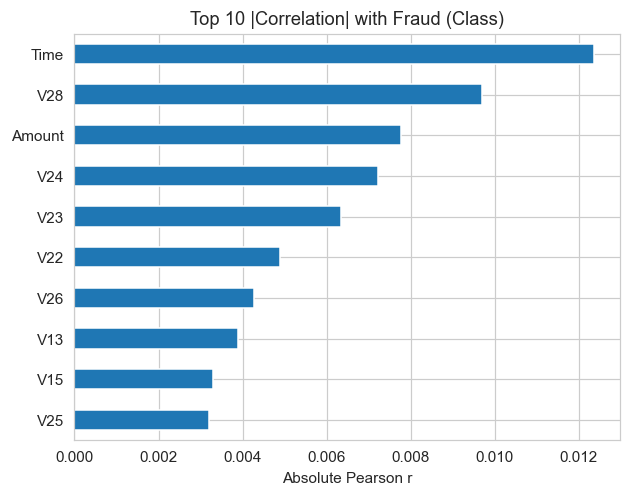

In [128]:
corr_with_class.abs().sort_values().head(10).plot.barh()
plt.title("Top 10 |Correlation| with Fraud (Class)")
plt.xlabel("Absolute Pearson r")
plt.show()

In [129]:
feature_cols = [c for c in df_cleaned.columns if c != "Class"]
X = df_cleaned[feature_cols]
y = df_cleaned["Class"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 划分数据集
X = df_cleaned.drop(columns=["Class"])
y = df_cleaned["Class"]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 使用 SMOTE 进行过采样
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 查看过采样后的类别分布
print(Counter(y_train_resampled))

Counter({0: 226602, 1: 226602})


In [ ]:
# 对少数类样本的 'Amount_log' 和 'Time_Hours' 进行扰动
fraud_indices = np.where(y_train_resampled == 1)[0]  # 找到欺诈样本的索引

# 对Amount加噪声
amount_col = 'Amount'
if amount_col in X_train_resampled.columns:
    noise = np.random.uniform(-0.05, 0.05, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, amount_col] *= (1 + noise)

# 对 Time_Hours 加时间偏移，裁剪到 0–24 小时
time_col = 'Time_Hours'
if time_col in X_train_resampled.columns:
    time_shift = np.random.randint(-2, 3, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, time_col] += time_shift
    X_train_resampled[time_col] = X_train_resampled[time_col].clip(lower=0, upper=24)

# 查看扰动后的数据
print(X_train_resampled.head())

       Time        V1        V2        V3        V4        V5        V6  \
0  144549.0  2.238954 -1.724499 -2.151484 -2.577803  0.993668  3.565492   
1   80716.0 -1.315062  1.630783  0.597001 -0.038359 -0.404580 -0.965712   
2  127116.0  1.908801  0.021184 -2.087997  0.129310  1.161468  0.605244   
3   91342.0  1.811257  0.316556  0.316751  3.880231  0.048454  1.020163   
4   29522.0  1.358817 -1.120881  0.550266 -1.547659 -1.194950  0.275448   

         V7        V8        V9  ...       V22       V23       V24       V25  \
0 -1.785957  0.860122 -1.264003  ... -0.049333  0.278442  0.684735 -0.219028   
1  0.212249  0.735381 -1.267926  ... -0.946773  0.323904  0.515632 -0.713000   
2 -0.022371  0.180296  0.283819  ...  1.095842 -0.044874 -1.689517  0.106098   
3 -0.734868  0.233651  0.681423  ...  0.700422  0.174064  0.702997 -0.212523   
4 -1.201843  0.212889 -2.094285  ... -0.636442  0.252758 -0.344160 -0.064282   

        V26       V27       V28  Amount  Time_Hours  Amount_log  
0 

In [ ]:
# Save the cleaned data
output_path = "cleaned_creditcard.csv"
df_cleaned.to_csv(output_path, index=False)
print(f"Dataset successfully saved to {output_path}")

Dataset successfully saved to cleaned_creditcard.csv


In [134]:
# 合并 SMOTE 后的训练数据与标签（可选加回标签列）保存为训练数据集
balanced_df = X_train_resampled.copy()
balanced_df["Class"] = y_train_resampled
balanced_df.to_csv("balanced_creditcard.csv", index=False)